In [1]:
import pandas as pd

df = pd.read_csv('E-commerce Customer Behavior Cleaned (1).csv')

print("✅ Data hasil cleaning berhasil dimuat untuk tahap Machine Learning!")
print(f"Ukuran dataset: {df.shape[0]} baris & {df.shape[1]} kolom.")
df.head()

✅ Data hasil cleaning berhasil dimuat untuk tahap Machine Learning!
Ukuran dataset: 348 baris & 15 kolom.


,Gender,Age,Membership Type,Total Spend,Items Purchased,Average Rating,Discount Applied,Days Since Last Purchase,Satisfaction Level,City_Chicago,City_Houston,City_Los Angeles,City_Miami,City_New York,City_San Francisco
0,0,29,3,1120.20,14,4.6,1,25,2,0,0,0,0,1,0
1,1,34,2,780.50,11,4.1,0,18,1,0,0,1,0,0,0
2,0,43,1,510.75,9,3.4,1,42,0,1,0,0,0,0,0
3,1,30,3,1480.30,19,4.7,0,12,2,0,0,0,0,0,1
4,1,27,2,720.40,13,4.0,1,55,0,0,0,0,1,0,0


In [2]:
print(df.shape)
print(df.columns)

(348, 15)
Index(['Gender', 'Age', 'Membership Type', 'Total Spend', 'Items Purchased',
       'Average Rating', 'Discount Applied', 'Days Since Last Purchase',
       'Satisfaction Level', 'City_Chicago', 'City_Houston',
       'City_Los Angeles', 'City_Miami', 'City_New York',
       'City_San Francisco'],
      dtype='str')


In [3]:
X = df.drop('Membership Type', axis=1)
y = df['Membership Type']

split data

In [4]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)
print("y_train :", y_train.shape)
print("y_test  :", y_test.shape)

X_train : (278, 14)
X_test  : (70, 14)
y_train : (278,)
y_test  : (70,)


In [5]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Feature scaling berhasil dilakukan")

Feature scaling berhasil dilakukan


K-Means Clustering

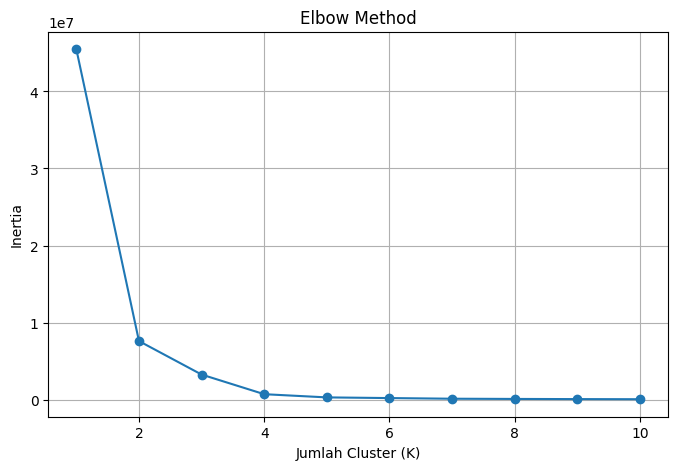

In [6]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(1, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X)

    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), inertia, marker='o')
plt.title('Elbow Method')
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('Inertia')
plt.grid(True)
plt.show()

In [7]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X)

print("10 cluster pertama:")
print(clusters[:10])

10 cluster pertama:
[1 2 0 1 2 0 1 2 0 1]


In [8]:
import pandas as pd

pd.Series(clusters).value_counts()

1    117
2    117
0    114
Name: count, dtype: int64

## Interpretasi Hasil K-Means

Berdasarkan grafik Elbow Method, titik siku (elbow point) ditemukan pada K=3. Oleh karena itu digunakan 3 cluster pada algoritma K-Means.

Hasil clustering menunjukkan distribusi cluster yang relatif seimbang, yaitu:



*   Cluster 0 : 114 data
*   Cluster 1: 117 data
*   Cluster 2: 117 data




Hal ini menunjukkan bahwa data pelanggan dapat dikelompokkan menjadi tiga kelompok utama yang memiliki karakteristik berbeda. Jumlah cluster yang terbentuk juga sejalan dengan kategori Membership Type pada dataset, yaitu Bronze, Silver, dan Gold.





**Logistic Regression**

In [9]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logreg.fit(X_train, y_train)
y_pred_lr = logreg.predict(X_test)

print("Model Logistic Regression berhasil dilatih")

Model Logistic Regression berhasil dilatih


In [16]:
print("5 data pertama hasil prediksi:")
print(y_pred_lr[:5])

5 data pertama hasil prediksi:
[3 1 2 3 1]


naive bayes

In [10]:
from sklearn.naive_bayes import GaussianNB
nb = GaussianNB()
nb.fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)

print("Model Naive Bayes berhasil dilatih")

Model Naive Bayes berhasil dilatih


In [11]:
print("5 data pertama hasil prediksi Naive Bayes:")
print(y_pred_nb[:5])

5 data pertama hasil prediksi Naive Bayes:
[3 1 2 3 1]


In [12]:
hasil_prediksi = pd.DataFrame({
    'Actual': y_test.values,
    'Logistic Regression': y_pred_lr,
    'Naive Bayes': y_pred_nb
})

hasil_prediksi.head(10)

,Actual,Logistic Regression,Naive Bayes
0,3,3,3
1,1,1,1
2,2,2,2
3,3,3,3
4,1,1,1
5,2,2,2
6,3,3,3
7,1,1,1
8,3,3,3
9,3,3,3


In [13]:
print("Jumlah data test:", len(y_test))
print("Jumlah prediksi LR:", len(y_pred_lr))
print("Jumlah prediksi NB:", len(y_pred_nb))

Jumlah data test: 70
Jumlah prediksi LR: 70
Jumlah prediksi NB: 70


In [14]:
hasil_prediksi.to_csv(
    "hasil_prediksi_vian.csv",
    index=False
)
print("File berhasil disimpan")

File berhasil disimpan


In [15]:
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

print("=== LOGISTIC REGRESSION ===")
print(classification_report(y_test, y_pred_lr))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))

=== LOGISTIC REGRESSION ===
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        23
           2       1.00      1.00      1.00        24
           3       1.00      1.00      1.00        23

    accuracy                           1.00        70
   macro avg       1.00      1.00      1.00        70
weighted avg       1.00      1.00      1.00        70

Confusion Matrix:
[[23  0  0]
 [ 0 24  0]
 [ 0  0 23]]


In [16]:
print( "NAIVE BAYES" )
print(classification_report(y_test, y_pred_nb))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_nb))

NAIVE BAYES
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        23
           2       1.00      1.00      1.00        24
           3       1.00      1.00      1.00        23

    accuracy                           1.00        70
   macro avg       1.00      1.00      1.00        70
weighted avg       1.00      1.00      1.00        70

Confusion Matrix:
[[23  0  0]
 [ 0 24  0]
 [ 0  0 23]]


In [17]:
from sklearn.metrics import accuracy_score
print("Accuracy Logistic Regression:",
      accuracy_score(y_test, y_pred_lr))
print("Accuracy Naive Bayes:",
      accuracy_score(y_test, y_pred_nb))

Accuracy Logistic Regression: 1.0
Accuracy Naive Bayes: 1.0
